# Parallel `decode_batch` Speedup Across Rust Decoders

Measures wall-clock speedup of `decode_batch(parallel=True)` vs `decode_batch(parallel=False)` for every Rust decoder in `qecdec` that exposes the `parallel` keyword.

Driven by the **Rotated Surface Code** under **phenomenological noise**, swept over distances $d \in \{5, 7, 9, 11\}$ (with `rounds = d`). For each $(d, \text{decoder}, \text{batch size})$ the notebook reports:

- Problem size: `num_chks`, `num_error_mechanisms` (= `num_vars`), `num_edges` in the Tanner graph.
- Tanner-graph degrees: avg / max for check nodes and variable nodes.
- Batch size, serial wall-clock time, parallel wall-clock time, and speedup.

UnionFind is omitted because its Python wrapper has no `parallel` kwarg.

Complements `benchmark_parallel_decode.ipynb` (BP & MemBP on BB[[144,12,12]]).

In [1]:
%reload_ext autoreload
%autoreload 2

import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qecdec.experiments import RotatedSurfaceCode_Memory
from qecdec.decoders import (
    BPDecoder,
    MemBPDecoder,
    DMemBPDecoder,
    DMemOffsetBPDecoder,
    RelayBPDecoder,
    MultiRelayBPDecoder,
)

## Helpers

In [2]:
def graph_stats(pcm: np.ndarray) -> dict:
    """Tanner-graph statistics for a {0,1}-valued parity-check matrix."""
    A = np.asarray(pcm)
    num_chks, num_vars = A.shape
    num_edges = int(A.sum())
    chk_deg = A.sum(axis=1)
    var_deg = A.sum(axis=0)
    return {
        "num_chks": int(num_chks),
        "num_error_mechanisms": int(num_vars),
        "num_edges": num_edges,
        "avg_chk_deg": float(chk_deg.mean()),
        "max_chk_deg": int(chk_deg.max()),
        "avg_var_deg": float(var_deg.mean()),
        "max_var_deg": int(var_deg.max()),
    }


def benchmark_decode_batch(
    decoder, syndromes, *, parallel: bool, warmup: int = 1, repeats: int = 5
) -> float:
    """Time decode_batch and return median wall-clock seconds."""
    for _ in range(warmup):
        decoder.decode_batch(syndromes, parallel=parallel)
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        decoder.decode_batch(syndromes, parallel=parallel)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))

## Configuration

In [3]:
ds = [5, 7, 9, 11]
batch_sizes = [100, 500, 2_000, 10_000]
max_batch_size = max(batch_sizes)

p = 0.01  # phenomenological noise strength
basis = "Z"
max_iter = 50  # for plain BP-family decoders

# RelayBP / MultiRelayBP hyperparams (kept small to bound runtime; we are
# measuring rayon's batch parallelism, not decoding quality).
relay_kwargs = dict(
    gamma0=0.125,
    gamma_dist_interval=(-0.25, 0.95),
    num_relays=4,
    pre_iter=50,
    max_iter_per_relay=50,
    stop_nconv=1,
)
num_chains = 4  # for MultiRelayBP

warmup, repeats = 1, 5

print(f"Number of logical CPUs: {os.cpu_count()}")
print(f"RAYON_NUM_THREADS = {os.environ.get('RAYON_NUM_THREADS', '(unset)')}")

Number of logical CPUs: 8
RAYON_NUM_THREADS = (unset)


## Run benchmarks

For each distance, build the experiment, sample one batch of `max_batch_size` syndromes, instantiate the six decoders, and time `decode_batch` in serial and parallel modes for each batch size.

In [4]:
def build_decoders(pcm: np.ndarray, prior: np.ndarray) -> dict:
    num_vars = pcm.shape[1]
    gamma = np.full(num_vars, 0.125, dtype=np.float64)
    return {
        "BP": BPDecoder(pcm, prior, max_iter=max_iter),
        "MemBP": MemBPDecoder(pcm, prior, gamma=0.125, max_iter=max_iter),
        "DMemBP": DMemBPDecoder(pcm, prior, gamma=gamma, max_iter=max_iter),
        "DMemOffsetBP": DMemOffsetBPDecoder(
            pcm, prior, gamma=gamma, max_iter=max_iter, norm=1.0, offset=0.0
        ),
        "RelayBP": RelayBPDecoder(pcm, prior, **relay_kwargs),
        "MultiRelayBP": MultiRelayBPDecoder(
            pcm, prior, num_chains=num_chains, **relay_kwargs
        ),
    }


rows = []
for d in ds:
    expmt = RotatedSurfaceCode_Memory(
        d=d,
        rounds=d,
        basis=basis,
        data_qubit_error_rate=p,
        prep_error_rate=p,
        meas_error_rate=p,
    )
    pcm, prior = expmt.chkmat, expmt.prior
    stats = graph_stats(pcm)
    print(
        f"\n=== d={d}  rounds={d}  basis={basis}  p={p} ===\n"
        f"    num_chks={stats['num_chks']}  num_error_mechanisms={stats['num_error_mechanisms']}  "
        f"num_edges={stats['num_edges']}\n"
        f"    chk_deg avg={stats['avg_chk_deg']:.2f} max={stats['max_chk_deg']}  "
        f"var_deg avg={stats['avg_var_deg']:.2f} max={stats['max_var_deg']}"
    )

    sampler = expmt.dem.compile_sampler()
    syndromes_all, _, _ = sampler.sample(max_batch_size)
    syndromes_all = syndromes_all.astype(np.uint8)

    decoders = build_decoders(pcm, prior)
    for name, decoder in decoders.items():
        for bs in batch_sizes:
            syndromes = syndromes_all[:bs]
            t_seq = benchmark_decode_batch(
                decoder, syndromes, parallel=False, warmup=warmup, repeats=repeats
            )
            t_par = benchmark_decode_batch(
                decoder, syndromes, parallel=True, warmup=warmup, repeats=repeats
            )
            speedup = t_seq / t_par
            rows.append(
                {
                    "d": d,
                    "decoder": name,
                    "batch_size": bs,
                    **stats,
                    "t_seq": t_seq,
                    "t_par": t_par,
                    "speedup": speedup,
                }
            )
            print(
                f"    {name:<14s} batch_size={bs:>5d}  "
                f"t_seq={t_seq:8.4f}s  t_par={t_par:8.4f}s  speedup={speedup:5.2f}x"
            )

df = pd.DataFrame(rows)


=== d=5  rounds=5  basis=Z  p=0.01 ===
    num_chks=72  num_error_mechanisms=186  num_edges=336
    chk_deg avg=4.67 max=6  var_deg avg=1.81 max=2
    BP             batch_size=  100  t_seq=  0.0022s  t_par=  0.0009s  speedup= 2.49x
    BP             batch_size=  500  t_seq=  0.0084s  t_par=  0.0033s  speedup= 2.56x
    BP             batch_size= 2000  t_seq=  0.0346s  t_par=  0.0131s  speedup= 2.64x
    BP             batch_size=10000  t_seq=  0.1710s  t_par=  0.0723s  speedup= 2.36x
    MemBP          batch_size=  100  t_seq=  0.0014s  t_par=  0.0007s  speedup= 2.03x
    MemBP          batch_size=  500  t_seq=  0.0062s  t_par=  0.0029s  speedup= 2.10x
    MemBP          batch_size= 2000  t_seq=  0.0268s  t_par=  0.0129s  speedup= 2.08x
    MemBP          batch_size=10000  t_seq=  0.1285s  t_par=  0.0552s  speedup= 2.33x
    DMemBP         batch_size=  100  t_seq=  0.0015s  t_par=  0.0009s  speedup= 1.69x
    DMemBP         batch_size=  500  t_seq=  0.0062s  t_par=  0.0030s  speedup

KeyboardInterrupt: 

## Results table

In [6]:
df

,d,decoder,batch_size,num_chks,num_error_mechanisms,num_edges,avg_chk_deg,max_chk_deg,avg_var_deg,max_var_deg,t_seq,t_par,speedup
0,5,BP,100,72,186,336,4.666667,6,1.806452,2,0.000823,0.000799,1.029241
1,5,BP,500,72,186,336,4.666667,6,1.806452,2,0.004032,0.002398,1.681687
2,5,BP,2000,72,186,336,4.666667,6,1.806452,2,0.016026,0.008820,1.816930
3,5,BP,10000,72,186,336,4.666667,6,1.806452,2,0.072906,0.042785,1.704013
4,5,MemBP,100,72,186,336,4.666667,6,1.806452,2,0.000603,0.000500,1.204398
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,11,RelayBP,10000,720,1992,3840,5.333333,6,1.927711,2,3.972669,1.346448,2.950482
92,11,MultiRelayBP,100,720,1992,3840,5.333333,6,1.927711,2,0.045065,0.016229,2.776801
93,11,MultiRelayBP,500,720,1992,3840,5.333333,6,1.927711,2,0.198679,0.082299,2.414097
94,11,MultiRelayBP,2000,720,1992,3840,5.333333,6,1.927711,2,0.896073,0.360531,2.485421


In [7]:
speedup_pivot = df.pivot_table(
    index=["d", "decoder"], columns="batch_size", values="speedup"
)
display(speedup_pivot.round(2))

batch_size       100    500    2000   10000
d  decoder                                 
5  BP             1.03   1.68   1.82   1.70
   DMemBP         1.07   1.51   1.60   1.51
   DMemOffsetBP   1.09   1.61   1.66   1.58
   MemBP          1.20   1.54   1.56   1.51
   MultiRelayBP   1.55   1.82   1.87   1.73
   RelayBP        1.28   1.49   1.29   1.52
7  BP             2.31   2.33   2.45   2.45
   DMemBP         1.70   1.94   2.14   2.09
   DMemOffsetBP   2.00   1.83   2.24   2.24
   MemBP          1.75   1.92   2.01   2.11
   MultiRelayBP   1.74   2.14   2.24   2.16
   RelayBP        1.87   2.12   2.19   2.14
9  BP             2.40   2.53   2.83   3.25
   DMemBP         2.61   2.75   2.81   2.80
   DMemOffsetBP   2.43   2.83   2.83   2.85
   MemBP          2.47   2.58   2.72   2.75
   MultiRelayBP   2.18   2.47   2.53   1.69
   RelayBP        2.27   2.77   2.85   2.87
11 BP             3.13   3.10   3.14   2.90
   DMemBP         2.88   2.55   2.74   2.84
   DMemOffsetBP   2.92   2.86   2.87   2.87
   MemBP          2.70   2.67   2.57   2.57
   MultiRelayBP   2.78   2.41   2.49   2.29
   RelayBP        2.89   2.80   2.80   2.95

## Plots

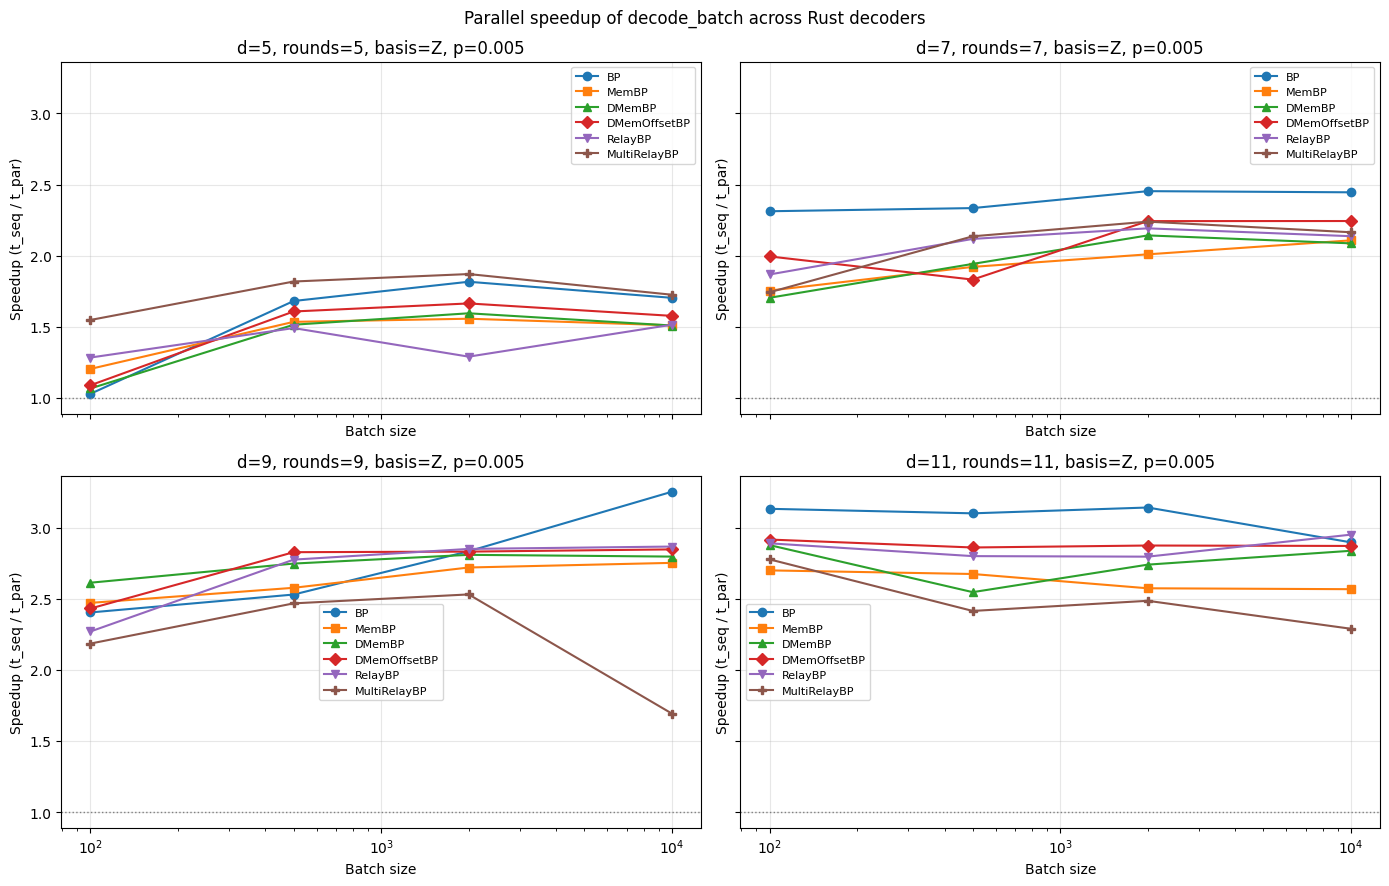

In [ ]:
decoder_names = ["BP", "MemBP", "DMemBP", "DMemOffsetBP", "RelayBP", "MultiRelayBP"]
markers = ["o", "s", "^", "D", "v", "P"]

ncols = 2
nrows = int(np.ceil(len(ds) / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(7 * ncols, 4.5 * nrows), sharex=True, sharey=True
)
axes = np.atleast_2d(axes).ravel()

for ax, d in zip(axes, ds):
    sub = df[df["d"] == d]
    for name, marker in zip(decoder_names, markers):
        s = sub[sub["decoder"] == name].sort_values("batch_size")
        if s.empty:
            continue
        ax.plot(s["batch_size"], s["speedup"], f"-{marker}", label=name)
    ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Speedup (t_seq / t_par)")
    ax.set_title(f"d={d}, rounds={d}, basis={basis}, p={p}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(ds) :]:
    ax.set_visible(False)

fig.suptitle("Parallel speedup of decode_batch across Rust decoders")
fig.tight_layout()
plt.show()

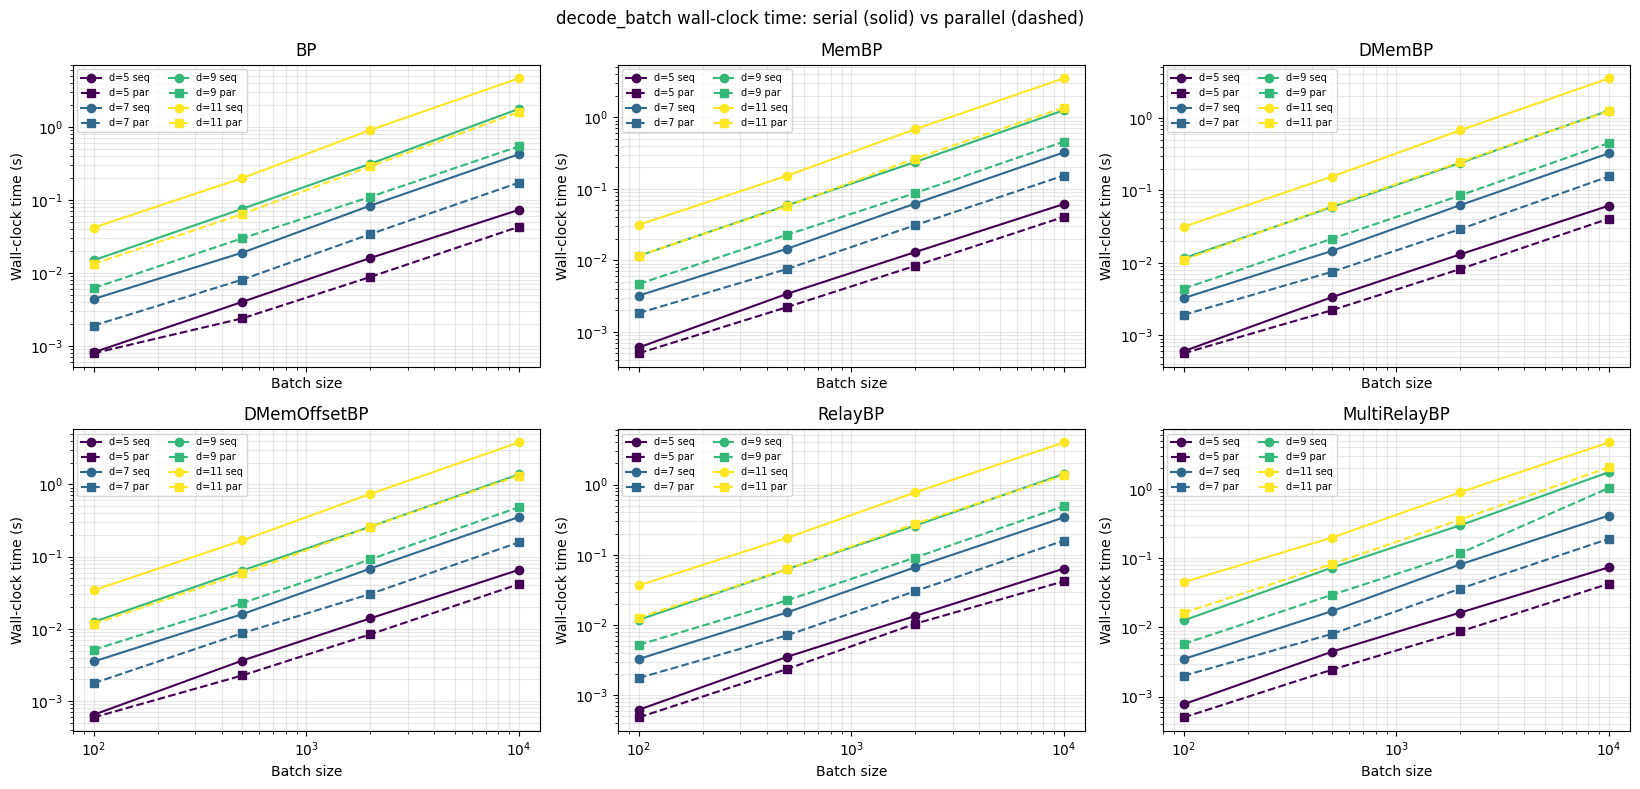

In [ ]:
cmap = plt.get_cmap("viridis")
d_colors = {d: cmap(i / max(1, len(ds) - 1)) for i, d in enumerate(ds)}

ncols = 3
nrows = int(np.ceil(len(decoder_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, name in zip(axes, decoder_names):
    sub = df[df["decoder"] == name]
    for d in ds:
        s = sub[sub["d"] == d].sort_values("batch_size")
        if s.empty:
            continue
        c = d_colors[d]
        ax.plot(s["batch_size"], s["t_seq"], "-o", color=c, label=f"d={d} seq")
        ax.plot(s["batch_size"], s["t_par"], "--s", color=c, label=f"d={d} par")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Wall-clock time (s)")
    ax.set_title(name)
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(fontsize=7, ncol=2)

for ax in axes[len(decoder_names) :]:
    ax.set_visible(False)

fig.suptitle("decode_batch wall-clock time: serial (solid) vs parallel (dashed)")
fig.tight_layout()
plt.show()

## Caveats

- Achievable speedup is capped by available cores and the `RAYON_NUM_THREADS` setting; the value printed near the top of the notebook indicates the upper bound.
- `RelayBPDecoder` and `MultiRelayBPDecoder` perform shot-dependent early termination, so their absolute wall-clock times mix per-iteration cost with convergence behavior. The `parallel=False` vs `parallel=True` comparison still isolates the rayon batch speedup because both modes solve the same shots with the same algorithm.
- BP/MemBP/DMemBP/DMemOffsetBP run a fixed number of iterations (`max_iter`) so their per-shot work is constant; the per-shot wall-clock time should be nearly independent of batch size, and `t_par` should track `t_seq / num_threads` for batches large enough to saturate the rayon pool.